# IDX Exchange DS Internship - Week Two - Data Exploration

* Load a minimum of 6 months of dataset into pandas.
* Explore distributions of ClosePrice (the target variable), LivingArea, Bedrooms, Bathrooms, LotSize.
* Restrict analysis to PropertyType = Residential and PropertySubType = SingleFamilyResidence (per task doc).
* Deliverable: Jupyter notebook 01_exploration.ipynb with basic EDA plots.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib import cbook
from scipy import stats

## Load In Data

In [2]:
# Read in sold: Jan, 2024 - April, 2026

sold_24_1 = pd.read_csv("../csv/CRMLSSold202401_filled.csv")
sold_24_2 = pd.read_csv("../csv/CRMLSSold202402.csv")
sold_24_3 = pd.read_csv("../csv/CRMLSSold202403_filled.csv")
sold_24_4 = pd.read_csv("../csv/CRMLSSold202404_filled.csv", low_memory=False)
sold_24_5 = pd.read_csv("../csv/CRMLSSold202405_filled.csv")
sold_24_6 = pd.read_csv("../csv/CRMLSSold202406_filled.csv")
sold_24_7 = pd.read_csv("../csv/CRMLSSold202407_filled.csv")
sold_24_8 = pd.read_csv("../csv/CRMLSSold202408.csv")
sold_24_9 = pd.read_csv("../csv/CRMLSSold202409.csv")
sold_24_10 = pd.read_csv("../csv/CRMLSSold202410.csv")
sold_24_11 = pd.read_csv("../csv/CRMLSSold202411.csv")
sold_24_12 = pd.read_csv("../csv/CRMLSSold202412.csv")
sold_25_1 = pd.read_csv("../csv/CRMLSSold202501_filled.csv")
sold_25_2 = pd.read_csv("../csv/CRMLSSold202502.csv")
sold_25_3 = pd.read_csv("../csv/CRMLSSold202503.csv")
sold_25_4 = pd.read_csv("../csv/CRMLSSold202504.csv")
sold_25_5 = pd.read_csv("../csv/CRMLSSold202505.csv")
sold_25_6 = pd.read_csv("../csv/CRMLSSold202506.csv", low_memory=False)
sold_25_7 = pd.read_csv("../csv/CRMLSSold202507.csv")
sold_25_8 = pd.read_csv("../csv/CRMLSSold202508.csv")
sold_25_9 = pd.read_csv("../csv/CRMLSSold202509.csv")
sold_25_10 = pd.read_csv("../csv/CRMLSSold202510.csv")
sold_25_11 = pd.read_csv("../csv/CRMLSSold202511.csv")
sold_25_12 = pd.read_csv("../csv/CRMLSSold202512.csv")
sold_26_1 = pd.read_csv("../csv/CRMLSSold202601.csv", low_memory=False)
sold_26_2 = pd.read_csv("../csv/CRMLSSold202602.csv")
sold_26_3 = pd.read_csv("../csv/CRMLSSold202603.csv")
sold_26_4 = pd.read_csv("../csv/CRMLSSold202604.csv")

In [3]:
# Combine into one dataframe

sold_list = [sold_24_1, sold_24_2, sold_24_3, sold_24_4, sold_24_5, sold_24_6,
                 sold_24_7, sold_24_8, sold_24_9, sold_24_10, sold_24_11, sold_24_12,
                 sold_25_1, sold_25_2, sold_25_3, sold_25_4, sold_25_5, sold_25_6,
                 sold_25_7, sold_25_8, sold_25_9, sold_25_10, sold_25_11, sold_25_12, 
                 sold_26_1, sold_26_2, sold_26_3, sold_26_4]
sold = pd.concat(sold_list)

In [4]:
# Filter on PropertyType == Residential and PropertySubType == SingleFamilyResidence

filtered_sold = sold[(sold["PropertyType"] == "Residential") & (sold["PropertySubType"] == "SingleFamilyResidence")]

## Plots

### ClosePrice

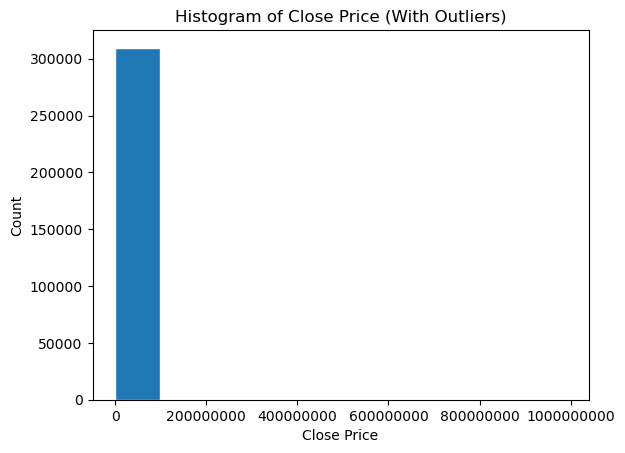

In [25]:
# Histogram of ClosePrice, with outliers

### Notes:
# Extreme outliers make this plot useless, must remove them

plt.hist(filtered_sold["ClosePrice"], edgecolor="w")
plt.title("Histogram of Close Price (With Outliers)")
plt.xlabel("Close Price")
plt.ylabel("Count")
plt.ticklabel_format(style='plain') #stops the scientific notation

In [26]:
# Removing outliers using the IQR rule

Q1 = filtered_sold["ClosePrice"].quantile(0.25)
Q3 = filtered_sold["ClosePrice"].quantile(0.75)
IQR = Q3 - Q1

# Computing lower bound doesn't matter, lower bound should be > 0
upper_bound = Q3 + 1.5 * IQR
print(upper_bound)

without_outliers = filtered_sold[(filtered_sold["ClosePrice"] > 0) & (filtered_sold["ClosePrice"] <= upper_bound)]

2637500.0


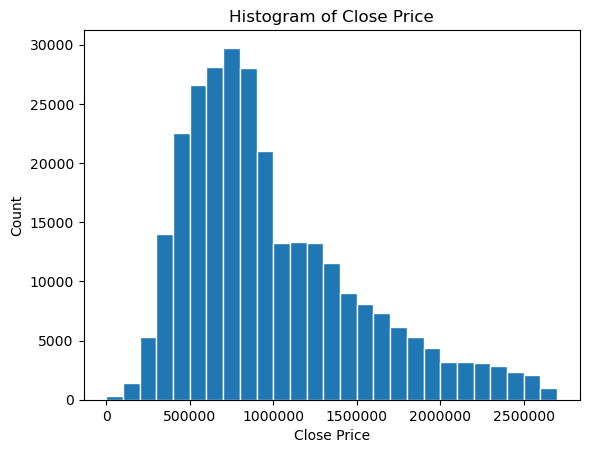

In [27]:
# Histogram of ClosePrice, using IQR outlier removal

plt.hist(without_outliers["ClosePrice"], edgecolor="w", bins=100_000*np.arange(28))
plt.title("Histogram of Close Price")
plt.xlabel("Close Price")
plt.ylabel("Count")
plt.ticklabel_format(style='plain') #stops the scientific notation

{'mean': np.float64(988749.4166955493), 'iqr': np.float64(675000.0), 'cilo': np.float64(848019.9266155805), 'cihi': np.float64(851980.0733844195), 'whishi': np.float64(2287500.0), 'whislo': np.float64(1.15), 'fliers': array([2340000., 2460000., 2300000., ..., 2400000., 2400000., 2425888.]), 'q1': np.float64(600000.0), 'med': np.float64(850000.0), 'q3': np.float64(1275000.0)}


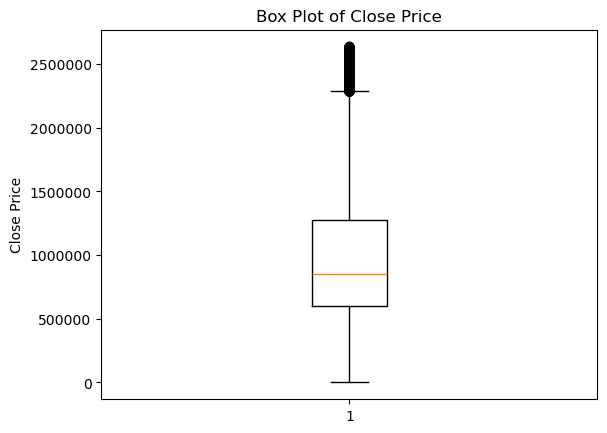

In [28]:
# Boxplot of Close Price, using IQR outlier removal

plt.boxplot(without_outliers["ClosePrice"])
plt.ylabel("Close Price")
plt.title("Box Plot of Close Price")
plt.ticklabel_format(style='plain', axis="y") #stops the scientific notation

stats = cbook.boxplot_stats(without_outliers["ClosePrice"])
print(stats[0]) 

In [29]:
# Checking to see how many properties were sold for suspiciously low prices

filtered_sold[filtered_sold["ClosePrice"] <= 100]

,Flooring,ViewYN,WaterfrontYN,BasementYN,PoolPrivateYN,OriginalListPrice,ListingKey,ListAgentEmail,CloseDate,ClosePrice,...,PostalCode,AssociationFee,LotSizeSquareFeet,MiddleOrJuniorSchoolDistrict,latfilled,lonfilled,BuyerAgentAOR,ListAgentAOR,OriginatingSystemName,OriginatingSystemSubName
18355,Wood,True,NaN,NaN,True,1249000.0,1077504198,NaN,2024-12-09,1.15,...,91307,NaN,17636.0,NaN,NaN,NaN,Conejo,Conejo,NaN,NaN
6517,"Carpet,Laminate",True,NaN,NaN,False,1350000.0,1117019091,claudialee@newstarrealty.com,2025-07-30,0.00,...,91780,NaN,11313.0,NaN,NaN,NaN,PasadenaFoothills,PasadenaFoothills,NaN,NaN
10591,"Carpet,Tile",True,NaN,NaN,True,1795000.0,1144223437,johnjay10@aol.com,2026-01-30,1.75,...,92211,594.0,11326.0,NaN,NaN,NaN,CaliforniaDesert,CaliforniaDesert,NaN,NaN


SECTION NOTES: ClosePrice has extremely high outliers that will need to be investigated and dealt with in order to make analysis possible. Likewise, listings that were sold for a very low amount need to be looked at more closely.

### LivingArea

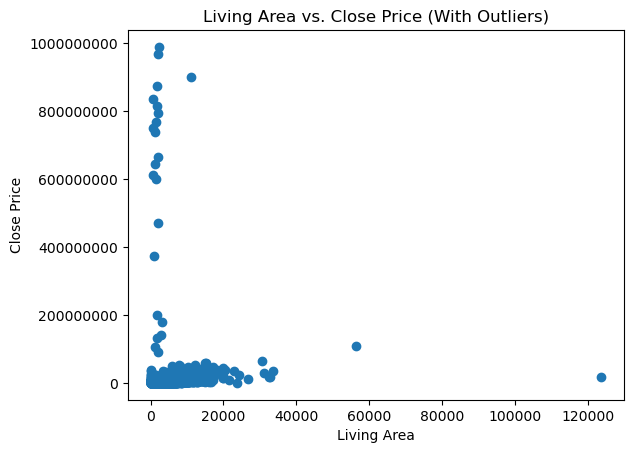

In [30]:
# Scatterplot of LivingArea vs. ClosePrice, including outliers

x = filtered_sold["LivingArea"]
y = filtered_sold["ClosePrice"]

plt.scatter(x, y)
plt.xlabel("Living Area")
plt.ylabel("Close Price")
plt.title("Living Area vs. Close Price (With Outliers)")
plt.ticklabel_format(style='plain') #stops the scientific notation

### Notes:
# Outliers once again make this plot useless.
# Why are there extremely expensive houses that have relatively small living space? Are they in very in-demand areas?

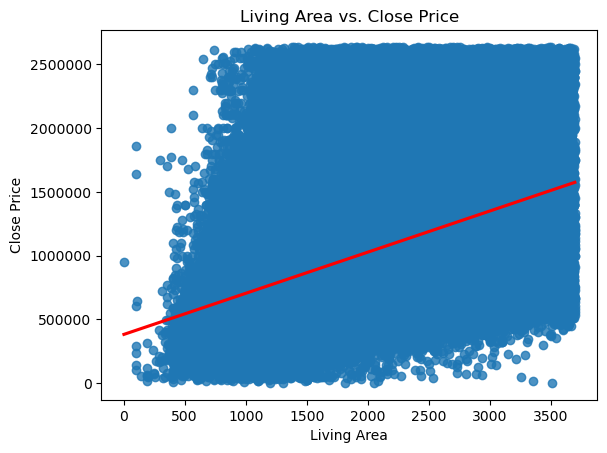

In [44]:
# Scatterplot of Living Area vs. Close Price, with IQR outlier removal

### Notes:
# IQR outlier removal makes this graph too scrunched to see much

Q1 = without_outliers["LivingArea"].quantile(0.25)
Q3 = without_outliers["LivingArea"].quantile(0.75)
IQR = Q3 - Q1

# Computing lower bound doesn't matter, it should be > 0
upper_bound = Q3 + 1.5 * IQR

living_area_IQR = without_outliers[(without_outliers["LivingArea"] > 0) & (without_outliers["LivingArea"] <= upper_bound)]

x = living_area_IQR["LivingArea"]
y = living_area_IQR["ClosePrice"]

sns.regplot(x=x, y=y, line_kws={"color": "red"})

plt.xlabel("Living Area")
plt.ylabel("Close Price")
plt.title("Living Area vs. Close Price")
plt.ticklabel_format(style='plain') #stops the scientific notation

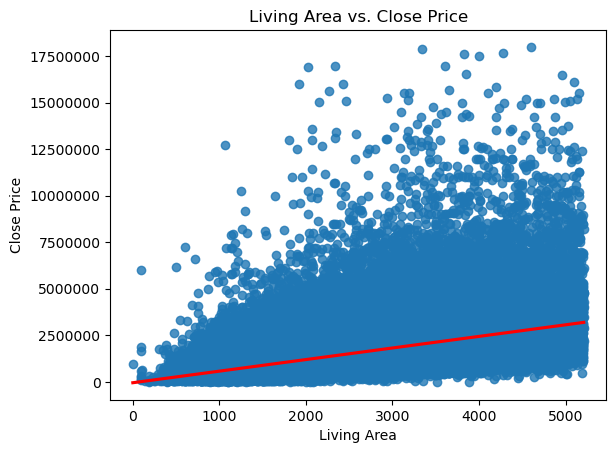

In [43]:
# Scatterplot of LivingArea vs. ClosePrice, using Z-score outlier removal

### Notes:
# Testing out z-score as a different outlier removal strategy

z_score_table = filtered_sold.copy()
z_score_table["ClosePrice_z_score"] = (filtered_sold["ClosePrice"] - filtered_sold["ClosePrice"].mean()) / filtered_sold["ClosePrice"].std()
z_score_table["LivingArea_z_score"] = (filtered_sold["LivingArea"] - filtered_sold["LivingArea"].mean()) / filtered_sold["LivingArea"].std()

living_area_filtered = z_score_table[np.abs(z_score_table["ClosePrice_z_score"]) < 3]
living_area_filtered = living_area_filtered[np.abs((living_area_filtered["LivingArea_z_score"]) < 3) & (living_area_filtered["LivingArea"] > 0)]

x = living_area_filtered["LivingArea"]
y = living_area_filtered["ClosePrice"]

sns.regplot(x=x, y=y, line_kws={"color": "red"})

plt.xlabel("Living Area")
plt.ylabel("Close Price")
plt.title("Living Area vs. Close Price")
plt.ticklabel_format(style='plain') #stops the scientific notation

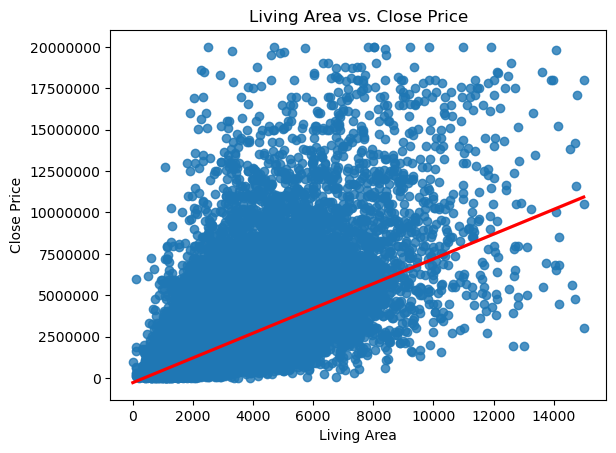

In [45]:
# Scatterplot of LivingArea vs. ClosePrice, using arbitrary outlier removal

### Notes:
# The cutoff points I've chosen here are somewhat arbitrary, but show the relationship well

# Remove outliers from ClosePrice
living_area_filter = filtered_sold[(filtered_sold["ClosePrice"] > 0 ) & (filtered_sold["ClosePrice"] <= 20_000_000)]

# Remove outliers from LivingArea
living_area_filter = living_area_filter[(living_area_filter["LivingArea"] > 0) & (living_area_filter["LivingArea"] <= 15_000)]

x = living_area_filter["LivingArea"]
y = living_area_filter["ClosePrice"]

sns.regplot(x=x, y=y, line_kws={"color": "red"})

plt.xlabel("Living Area")
plt.ylabel("Close Price")
plt.title("Living Area vs. Close Price")
plt.ticklabel_format(style='plain') #stops the scientific notation

Text(0.5, 1.0, 'Living Area vs. Close Price (Log)')

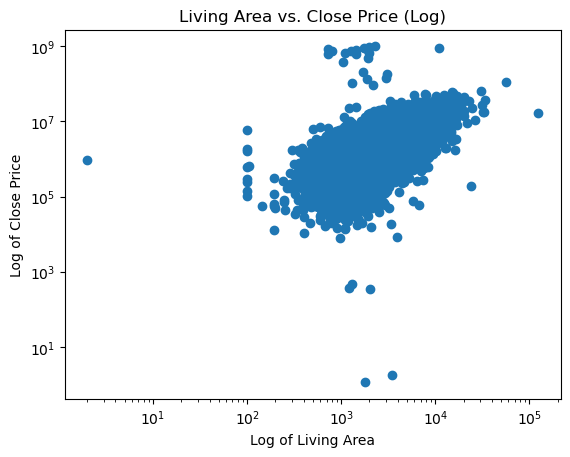

In [32]:
# Scatterplot of Living Area vs. Close Price, logged axes, including outliers

### Notes:
# Clear correlation. 

x = filtered_sold["LivingArea"]
y = filtered_sold["ClosePrice"]

plt.scatter(x, y)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Log of Living Area")
plt.ylabel("Log of Close Price")
plt.title("Living Area vs. Close Price (Log)")

SECTION NOTES: In general, there seems to be a moderate positive correlation between LivingArea and ClosePrice. Choosing how to remove outliers will be very important down the line.

### Bedrooms

In [50]:
filtered_sold["BedroomsTotal"].max(), filtered_sold["BedroomsTotal"].median(), filtered_sold["BedroomsTotal"].quantile(0.75)

(45.0, 3.0, np.float64(4.0))

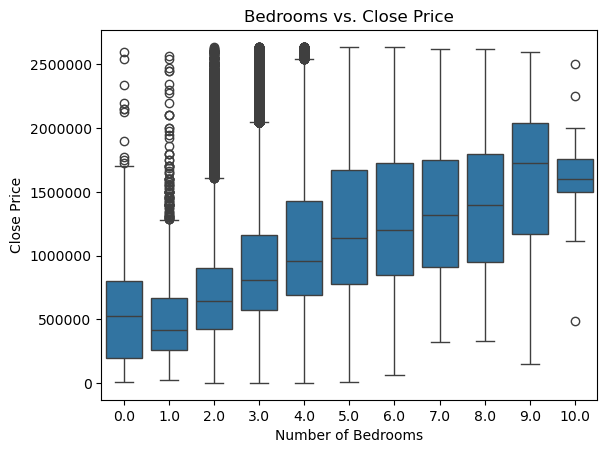

In [53]:
# Boxplots of Bedrooms vs. ClosePrice, using arbitrary outlier removal

bedroom_filter = without_outliers[without_outliers["BedroomsTotal"] <= 10]

x = bedroom_filter["BedroomsTotal"]
y = bedroom_filter["ClosePrice"]

sns.boxplot(x=x, y=y)
#sns.lineplot(x=x, y=y, color="red")

plt.xlabel("Number of Bedrooms")
plt.ylabel("Close Price")
plt.title("Bedrooms vs. Close Price")
plt.ticklabel_format(style='plain', axis="y") #stops the scientific notation

SECTION NOTES: There is a positive correlation between number of bedrooms and close price.

### Bathrooms

In [56]:
filtered_sold["BathroomsTotalInteger"].max(), filtered_sold["BathroomsTotalInteger"].median(), filtered_sold["BathroomsTotalInteger"].quantile(0.75)

(175.0, 2.0, np.float64(3.0))

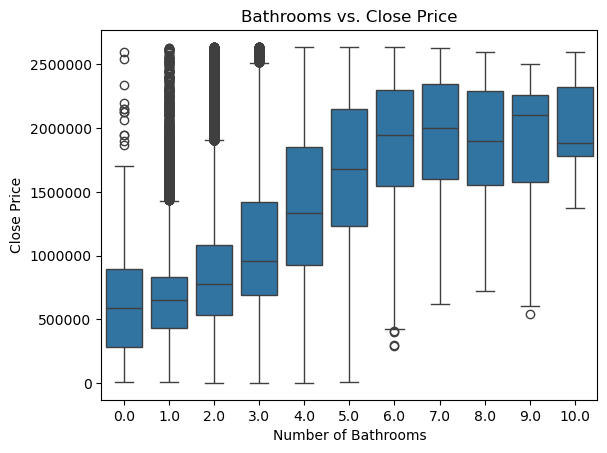

In [58]:
# Boxplot of Bathrooms vs. Close Price, with arbitrary outlier removal

bathroom_filter = without_outliers[without_outliers["BathroomsTotalInteger"] <= 10]

x = bathroom_filter["BathroomsTotalInteger"]
y = bathroom_filter["ClosePrice"]

sns.boxplot(x=x, y=y)
#sns.lineplot(x=x, y=y, color="red")

plt.xlabel("Number of Bathrooms")
plt.ylabel("Close Price")
plt.title("Bathrooms vs. Close Price")
plt.ticklabel_format(style='plain', axis="y") #stops the scientific notation

SECTION NOTES: There is a postive correlation between number of bathrooms and close price.

### LotSize

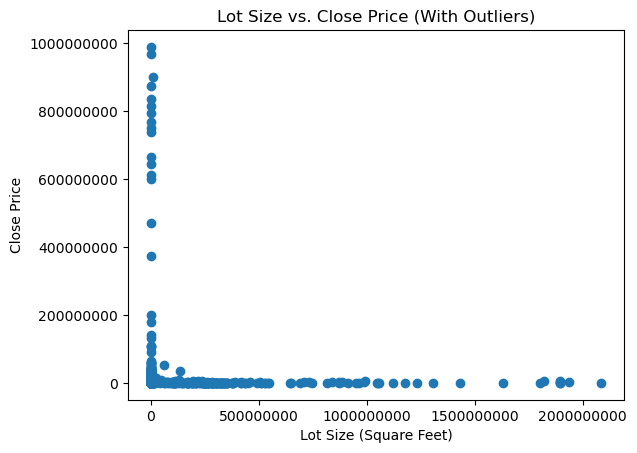

In [7]:
# Scatterplot of Lot Size vs. Close Price, with outliers

x = filtered_sold["LotSizeSquareFeet"]
y = filtered_sold["ClosePrice"]

plt.scatter(x, y)

plt.xlabel("Lot Size (Square Feet)")
plt.ylabel("Close Price")
plt.title("Lot Size vs. Close Price (With Outliers)")
plt.ticklabel_format(style='plain') #stops the scientific notation

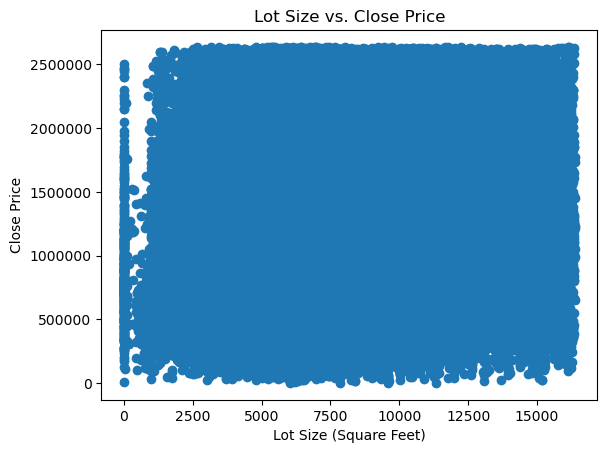

In [8]:
# Scatterplot of Lot Size vs. Close Price, using IQR outlier removal

### Notes:
# IQR outlier removal defintely doesn't work here, just creates a big blob

Q1 = without_outliers["LotSizeSquareFeet"].quantile(0.25)
Q3 = without_outliers["LotSizeSquareFeet"].quantile(0.75)
IQR = Q3 - Q1

# Computing lower bound doesn't matter, it should be > 0
upper_bound = Q3 + 1.5 * IQR

lot_size_IQR = without_outliers[(without_outliers["LotSizeSquareFeet"] > 0) & (without_outliers["LotSizeSquareFeet"] <= upper_bound)]

x = lot_size_IQR["LotSizeSquareFeet"]
y = lot_size_IQR["ClosePrice"]

plt.scatter(x, y)

plt.xlabel("Lot Size (Square Feet)")
plt.ylabel("Close Price")
plt.title("Lot Size vs. Close Price")
plt.ticklabel_format(style='plain') #stops the scientific notation

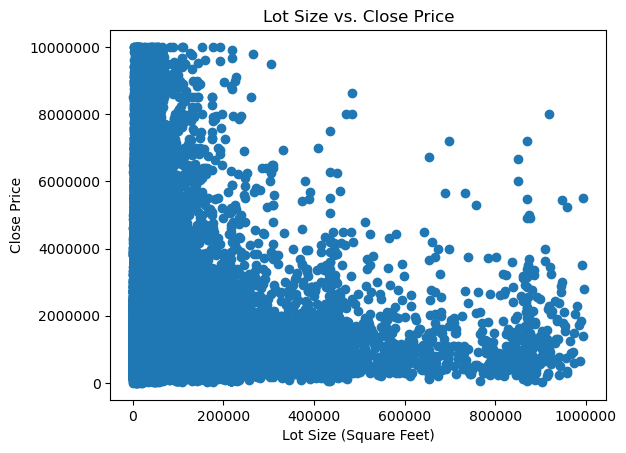

In [9]:
# Scatterplot of Lot Size vs. Close Price, using arbitrary outlier removal

lot_size_filtered = filtered_sold[(filtered_sold["ClosePrice"] > 0 ) & (filtered_sold["ClosePrice"] <= 10_000_000)]
lot_size_filtered = lot_size_filtered[(lot_size_filtered["LotSizeSquareFeet"] > 0) & (lot_size_filtered["LotSizeSquareFeet"] <= 1_000_000)]

x = lot_size_filtered["LotSizeSquareFeet"]
y = lot_size_filtered["ClosePrice"]

plt.scatter(x, y)

plt.xlabel("Lot Size (Square Feet)")
plt.ylabel("Close Price")
plt.title("Lot Size vs. Close Price")
plt.ticklabel_format(style='plain') #stops the scientific notation

### Notes:
# Interesting distribution!
# LotSize doesn't seem to actually predict ClosePrice all that well

Text(0.5, 1.0, 'Lot Size vs. Close Price (Log)')

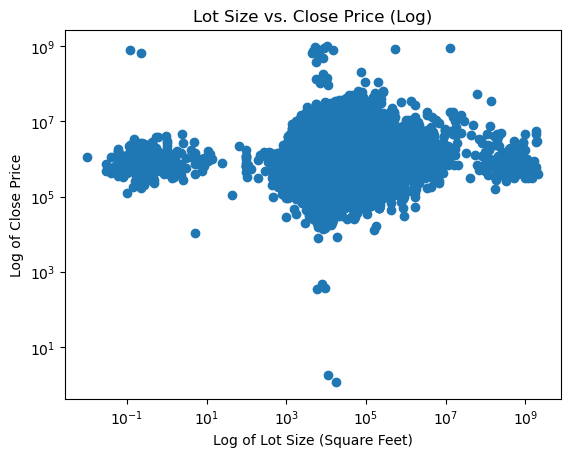

In [24]:
# Scatterplot of Lot Size vs. Close Price, logged axes, including outliers

### Notes:
# Still no clear correlation, but useful to see "bubbles" of values

x = filtered_sold["LotSizeSquareFeet"]
y = filtered_sold["ClosePrice"]

plt.scatter(x, y)

plt.xscale('log')
plt.yscale('log')

plt.xlabel("Log of Lot Size (Square Feet)")
plt.ylabel("Log of Close Price")
plt.title("Lot Size vs. Close Price (Log)")

SECTION NOTES: Strangely, LotSizeSquareFeet seems to have very little correlation with ClosePrice. Used LotSizeSquareFeet for this, would be intersting to see if anything changes if LotSizeArea or LotSizeAcres are used instead.